<a href="https://colab.research.google.com/github/jonitodev/pcvk26_8_joniyogakusuma/blob/main/Week5_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Joni Yoga Kusuma'
NIM = '254107023003'
NO_ABSEN = 8
assert NIM.isdigit() and len(NIM) >= 3
N = int(NIM[-3:])
PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1),
}
try:
    zona = zoneinfo.ZoneInfo('Asia/Jakarta')
except zoneinfo.ZoneInfoNotFoundError:
    zona = datetime.timezone(datetime.timedelta(hours=7), name='WIB')
waktu = datetime.datetime.now(zona)
print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
print('ABSEN  :', NO_ABSEN)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Joni Yoga Kusuma
NIM    : 254107023003 | N = 3
ABSEN  : 8
bins   : 64
clip   : 2.5
tile   : 5
L      : 2
WAKTU  : 2026-10-08 10:20:50 WIB
SISTEM : 3.12.10 Windows-11-10.0.26300-SP0
TOKEN  : 40999f8c3d44e5a8


# Week 5 - Histogram, Equalization, dan Dithering
**Joni Yoga Kusuma | 254107023003 | Absen 8**

Gambar sudah tersimpan dalam notebook. Buka di Colab/Jupyter dan jalankan semua sel dari atas.
Parameter NIM: **64 bin, clipLimit 2,5, grid 5 × 5, dan 2 level dithering**.

In [ ]:
import base64
from pathlib import Path
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Jika pustaka belum tersedia, jalankan sekali:
# %pip install numpy matplotlib opencv-python-headless

plt.rcParams.update({'figure.dpi':100, 'font.size':10, 'axes.titlesize':10})
CONTOH = Path('data_week5')
BASE = CONTOH / NIM
CONTOH.mkdir(exist_ok=True)
BASE.mkdir(exist_ok=True)

In [ ]:
def baca(nama):
    folder = CONTOH if nama.startswith('lena') else BASE
    img = cv.imdecode(np.fromfile(folder/nama, dtype=np.uint8), cv.IMREAD_COLOR)
    if img is None:
        raise ValueError(f'Gagal membaca {nama}')
    return img

def abu(img):
    return cv.cvtColor(img, cv.COLOR_BGR2GRAY)

def tampil(daftar, label, kolom=3, ukuran=4):
    baris = (len(daftar)+kolom-1)//kolom
    fig, axes = plt.subplots(baris,kolom,figsize=(ukuran*kolom,3.3*baris),
                             squeeze=False,layout='constrained')
    for ax,img,nama in zip(axes.flat,daftar,label):
        if img.ndim==2:
            ax.imshow(img,cmap='gray',vmin=0,vmax=255,interpolation='nearest')
        else:
            ax.imshow(cv.cvtColor(img,cv.COLOR_BGR2RGB),interpolation='nearest')
        ax.set_title(f'{NIM}\n{nama}')
        ax.axis('off')
    for ax in list(axes.flat)[len(daftar):]:
        ax.axis('off')
    plt.show()

def area(img, kotak):
    x0,y0,x1,y1 = kotak
    h,w = img.shape[:2]
    return img[int(y0*h):int(y1*h),int(x0*w):int(x1*w)]

lena = baca('lena.jpg')
lena_lc = baca('lena_lc.jpg')
ktm = {nama:baca(nama) for nama in ['KTM1a.jpg','KTM1b.jpg','KTM1c.jpg','KTM1d.jpg']}
ROI_TEKS = (0.20,0.65,0.65,0.84)
ROI_NOISE = (0.72,0.20,0.80,0.45)

## E-1 PERCOBAAN HISTOGRAM
### Histogram RGB
Hitung jumlah piksel pada setiap intensitas, lalu tampilkan grafik merah, hijau, dan biru.

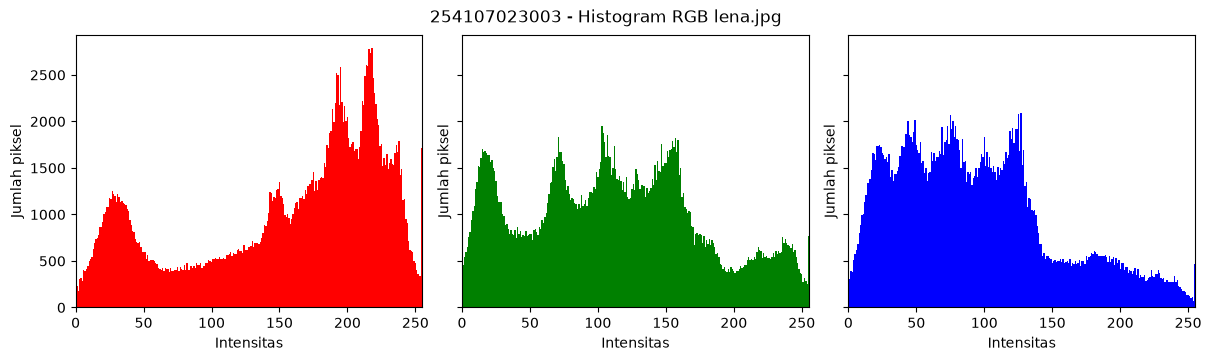

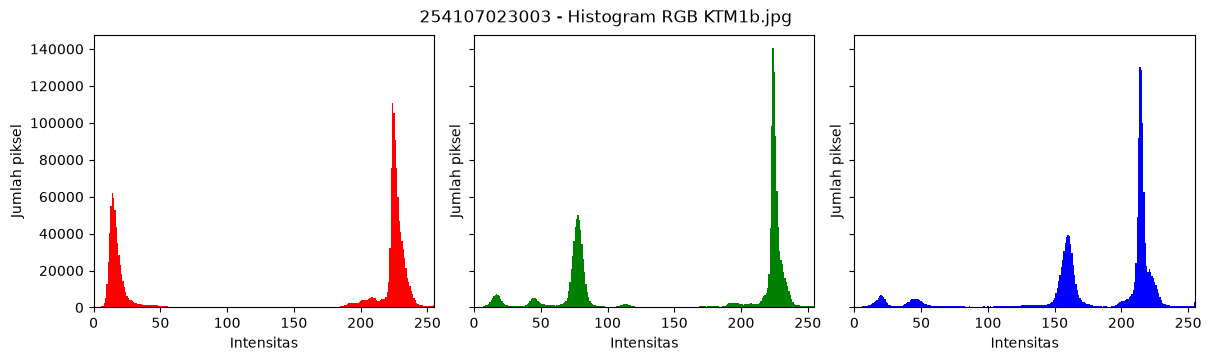

In [ ]:
def histogram_manual(gray):
    h = np.zeros(256,dtype=np.int64)
    for y in range(gray.shape[0]):
        for x in range(gray.shape[1]):
            h[gray[y,x]] += 1
    assert h.sum()==gray.size
    return h

def histogram_rgb(img,nama):
    fig,axes=plt.subplots(1,3,figsize=(12,3.5),sharey=True,layout='constrained')
    for ax,i,warna in zip(axes,[2,1,0],['red','green','blue']):
        h=histogram_manual(img[:,:,i])
        ax.bar(np.arange(256),h,width=1,color=warna)
        ax.set(xlabel='Intensitas',ylabel='Jumlah piksel',xlim=(0,255))
    fig.suptitle(f'{NIM} - Histogram RGB {nama}')
    plt.show()

histogram_rgb(lena,'lena.jpg')
histogram_rgb(ktm['KTM1b.jpg'],'KTM1b.jpg')

### 1. Bandingkan manual, NumPy, dan OpenCV
Hitung selisih maksimum ketiga histogram pada Lena dan KTM1b.

In [ ]:
for nama,img in [('lena.jpg',lena),('KTM1b.jpg',ktm['KTM1b.jpg'])]:
    gray=abu(img)
    h_manual=histogram_manual(gray)
    h_numpy,_=np.histogram(gray,bins=256,range=(0,256))
    h_opencv=cv.calcHist([gray],[0],None,[256],[0,256]).ravel().astype(np.int64)
    selisih=[int(np.abs(h_manual-h_numpy).max()),
             int(np.abs(h_manual-h_opencv).max()),
             int(np.abs(h_numpy-h_opencv).max())]
    assert selisih==[0,0,0]
    print(nama)
    print('Manual - NumPy :',selisih[0])
    print('Manual - OpenCV:',selisih[1])
    print('NumPy - OpenCV :',selisih[2])

lena.jpg
Manual - NumPy : 0
Manual - OpenCV: 0
NumPy - OpenCV : 0


KTM1b.jpg
Manual - NumPy : 0
Manual - OpenCV: 0
NumPy - OpenCV : 0


**Analisis:** Ketiga metode memiliki selisih 0. Hasilnya sama karena bin dan rentang intensitasnya sama.

### 2. Histogram ternormalisasi dan CDF
Bandingkan empat foto KTM dengan pencahayaan berbeda.

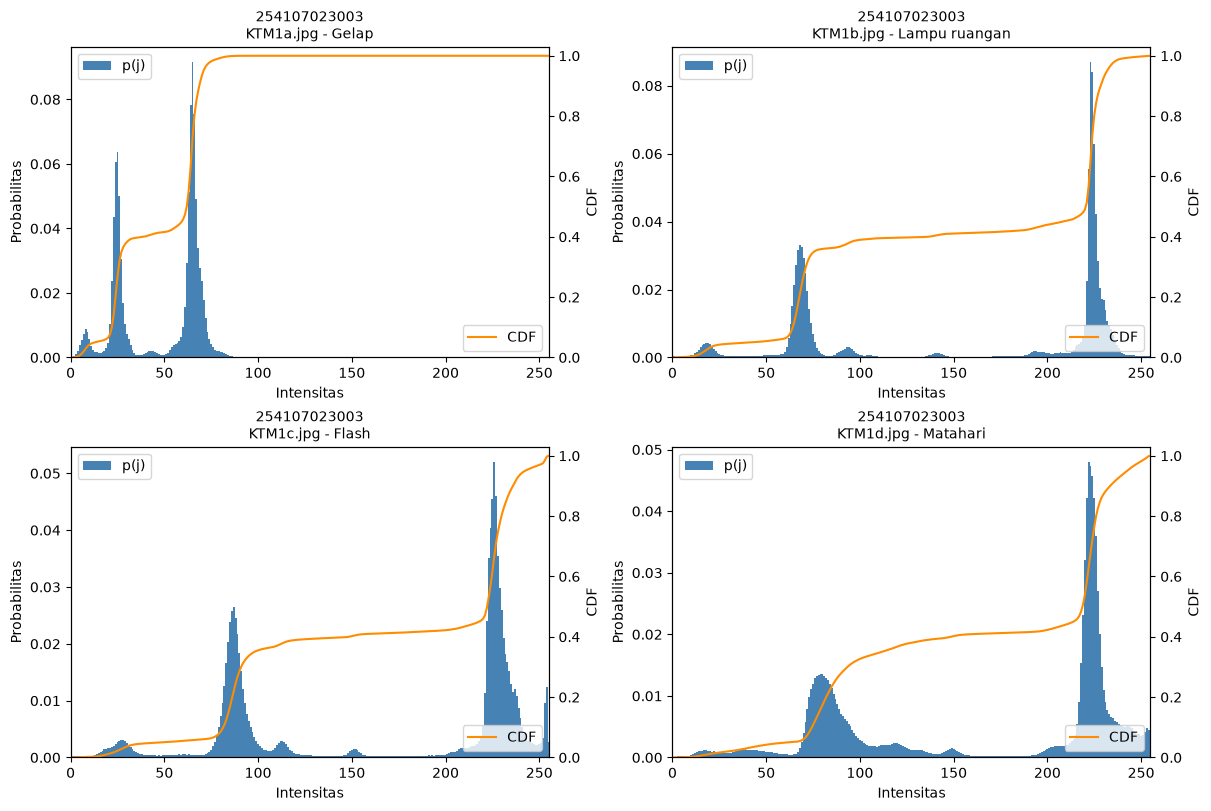

Citra           Rerata     CDF(63)    CDF(127)
KTM1a.jpg        48.28      0.5539      1.0000
KTM1b.jpg       158.96      0.0819      0.3979
KTM1c.jpg       169.19      0.0569      0.3928
KTM1d.jpg       167.93      0.0507      0.3797


In [ ]:
kondisi=['Gelap','Lampu ruangan','Flash','Matahari']
statistik=[]
fig,axes=plt.subplots(2,2,figsize=(12,8),layout='constrained')
for ax,(nama,img),cahaya in zip(axes.flat,ktm.items(),kondisi):
    gray=abu(img)
    h=np.bincount(gray.ravel(),minlength=256)
    p=h/gray.size
    cdf=np.cumsum(p)
    assert np.isclose(p.sum(),1) and np.isclose(cdf[-1],1)
    ax.bar(np.arange(256),p,width=1,color='steelblue',label='p(j)')
    ax.set(title=f'{NIM}\n{nama} - {cahaya}',xlabel='Intensitas',
           ylabel='Probabilitas',xlim=(0,255))
    kanan=ax.twinx()
    kanan.plot(cdf,color='darkorange',label='CDF')
    kanan.set(ylabel='CDF',ylim=(0,1.03))
    ax.legend(loc='upper left');kanan.legend(loc='lower right')
    statistik.append((nama,float(gray.mean()),float(cdf[63]),float(cdf[127])))
plt.show()
print(f'{"Citra":<12}{"Rerata":>10}{"CDF(63)":>12}{"CDF(127)":>12}')
for nama,rerata,c63,c127 in statistik:
    print(f'{nama:<12}{rerata:>10.2f}{c63:>12.4f}{c127:>12.4f}')

**Analisis:** KTM1a paling gelap (rerata 48,28); CDF-nya naik cepat pada intensitas rendah dan sudah mencapai 1 pada intensitas 127. KTM1c paling terang (169,19), sedikit di atas KTM1d (167,93). CDF KTM1c naik pada intensitas lebih tinggi karena pencahayaan flash.

### 3. Histogram 64 bin dan 256 bin
Gunakan KTM1b untuk melihat pengaruh pengurangan bin.

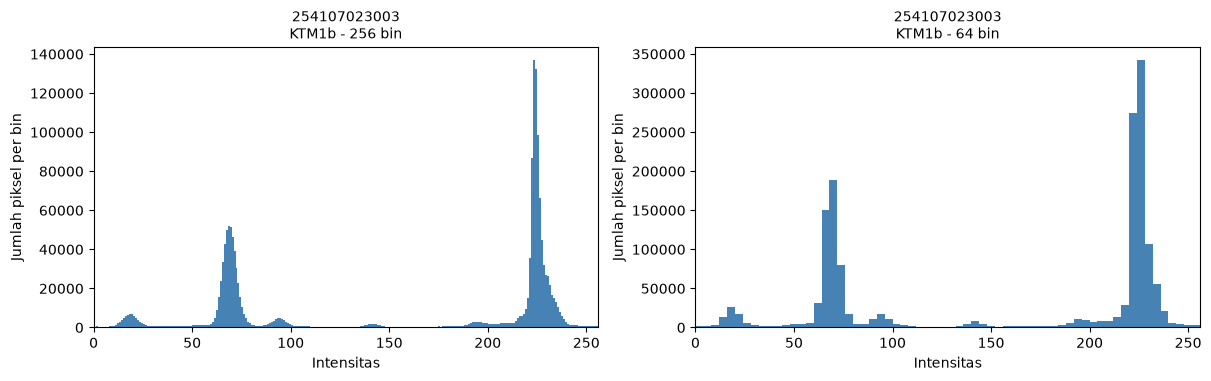

In [ ]:
gray_b=abu(ktm['KTM1b.jpg'])
fig,axes=plt.subplots(1,2,figsize=(12,3.7),layout='constrained')
for ax,bins in zip(axes,[256,PARAM['bins']]):
    h,tepi=np.histogram(gray_b,bins=bins,range=(0,256))
    assert h.sum()==gray_b.size
    ax.bar(tepi[:-1],h,width=np.diff(tepi),align='edge',color='steelblue')
    ax.set(title=f'{NIM}\nKTM1b - {bins} bin',xlabel='Intensitas',
           ylabel='Jumlah piksel per bin',xlim=(0,256))
plt.show()

**Analisis:** Satu bin pada histogram 64 bin menggabungkan 4 intensitas. Detail puncak kecil pada grafik berkurang, tetapi gambar aslinya tidak berubah.

## E-2 PERCOBAAN HISTOGRAM EQUALIZATION
### 1. Equalization manual
Gunakan CDF untuk memetakan intensitas. Pada contoh berwarna, proses setiap kanal B/G/R.

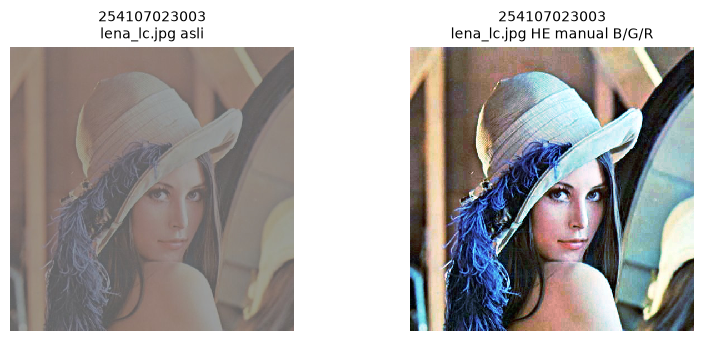

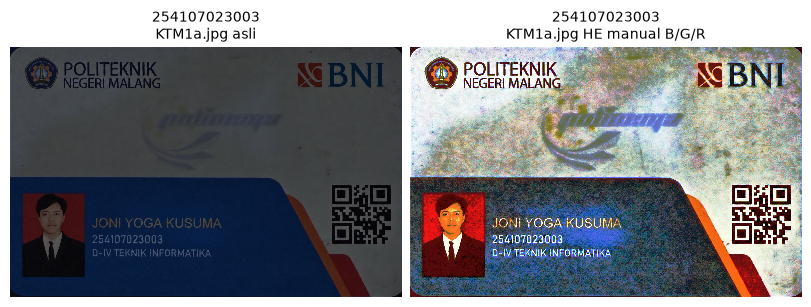

In [ ]:
def he_manual(gray,normalisasi_min=False):
    h=np.bincount(gray.ravel(),minlength=256)
    cdf=np.cumsum(h,dtype=np.float64)/gray.size
    if normalisasi_min:
        terisi=np.flatnonzero(h)
        if len(terisi)==1:
            return gray.copy()
        minimum=cdf[terisi[0]]
        cdf=(cdf-minimum)/(1-minimum)
    lut=np.clip(np.rint(255*cdf),0,255).astype(np.uint8)
    return lut[gray]

def he_perkanal(img,manual=False):
    if manual:
        return cv.merge([he_manual(c) for c in cv.split(img)])
    return cv.merge([cv.equalizeHist(c) for c in cv.split(img)])

for nama,img in [('lena_lc.jpg',lena_lc),('KTM1a.jpg',ktm['KTM1a.jpg'])]:
    tampil([img,he_perkanal(img,manual=True)],
           [f'{nama} asli',f'{nama} HE manual B/G/R'],kolom=2)

### 2. Bandingkan dengan OpenCV
Hitung selisih hasil manual dan `cv.equalizeHist`.

lena_lc.jpg
Selisih manual vs OpenCV B/G/R: 0
Selisih manual CDF dasar vs OpenCV grayscale: 0
Selisih manual CDF_min vs OpenCV grayscale: 0


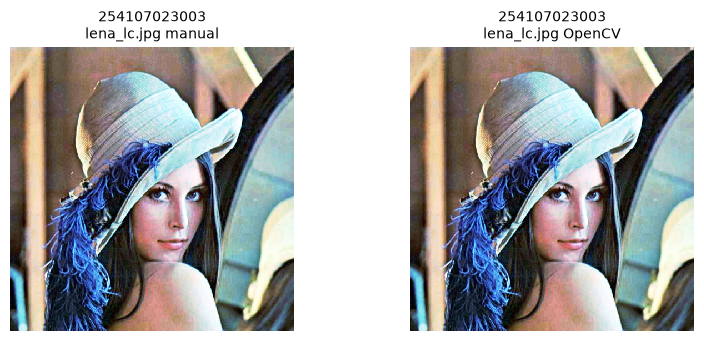

KTM1a.jpg


Selisih manual vs OpenCV B/G/R: 1
Selisih manual CDF dasar vs OpenCV grayscale: 0
Selisih manual CDF_min vs OpenCV grayscale: 0


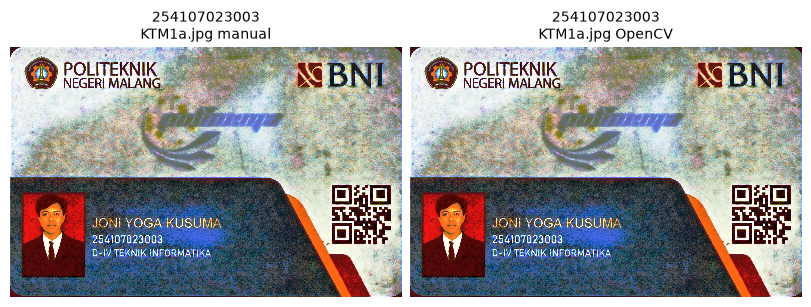

In [ ]:
def beda(a,b):
    return int(np.abs(a.astype(np.int16)-b.astype(np.int16)).max())

for nama,img in [('lena_lc.jpg',lena_lc),('KTM1a.jpg',ktm['KTM1a.jpg'])]:
    manual=he_perkanal(img,manual=True)
    opencv=he_perkanal(img)
    gray=abu(img)
    print(nama)
    print('Selisih manual vs OpenCV B/G/R:',beda(manual,opencv))
    print('Selisih manual CDF dasar vs OpenCV grayscale:',beda(he_manual(gray),cv.equalizeHist(gray)))
    print('Selisih manual CDF_min vs OpenCV grayscale:',
          beda(he_manual(gray,normalisasi_min=True),cv.equalizeHist(gray)))
    tampil([manual,opencv],[f'{nama} manual',f'{nama} OpenCV'],kolom=2)

**Analisis:** Pada Lena LC, selisih manual dan OpenCV adalah 0. Pada KTM1a, selisih B/G/R sebesar 1, sedangkan grayscale 0. Selisih kecil dapat muncul karena normalisasi CDF dan pembulatan yang berbeda.

### 3. Ekualisasi B/G/R, Y, V, dan L
Bandingkan perubahan warna pada Lena dan KTM1d.

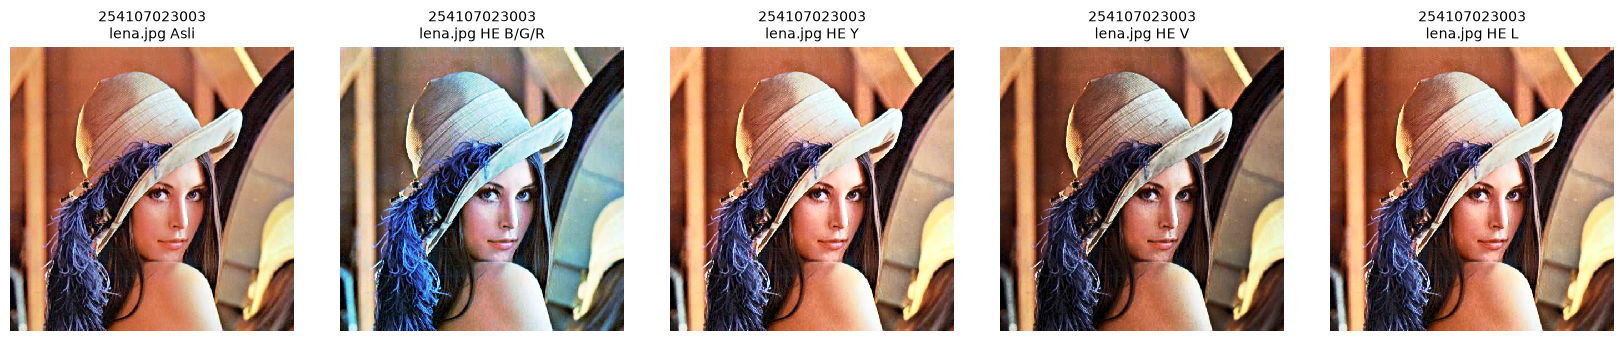

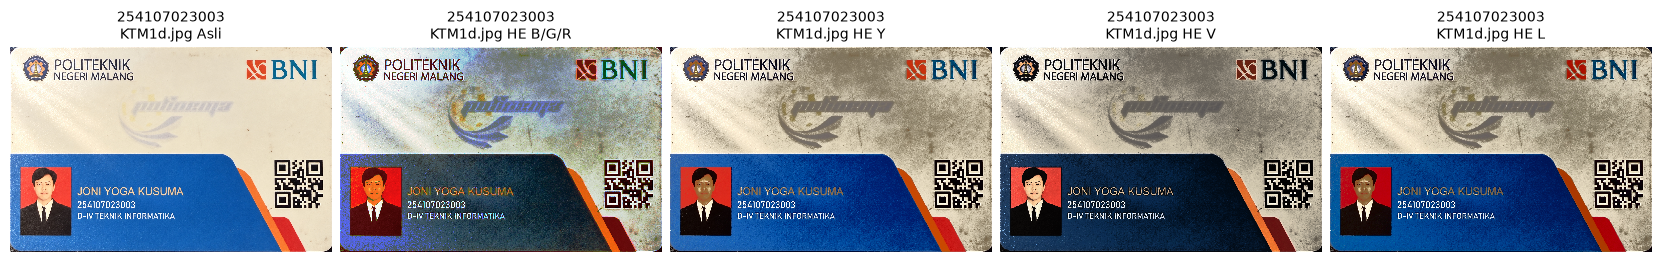

In [ ]:
def he_terang(img,ruang='Y',lokal=False):
    konversi={
        'Y':(cv.COLOR_BGR2YCrCb,cv.COLOR_YCrCb2BGR,0),
        'V':(cv.COLOR_BGR2HSV,cv.COLOR_HSV2BGR,2),
        'L':(cv.COLOR_BGR2LAB,cv.COLOR_LAB2BGR,0)}
    maju,balik,kanal=konversi[ruang]
    hasil=cv.cvtColor(img,maju)
    if lokal:
        alat=cv.createCLAHE(clipLimit=PARAM['clip'],
                           tileGridSize=(PARAM['tile'],PARAM['tile']))
        hasil[:,:,kanal]=alat.apply(hasil[:,:,kanal])
    else:
        hasil[:,:,kanal]=cv.equalizeHist(hasil[:,:,kanal])
    return cv.cvtColor(hasil,balik)

warna_ktm={}
for nama,img in [('lena.jpg',lena),('KTM1d.jpg',ktm['KTM1d.jpg'])]:
    hasil={'Asli':img,'HE B/G/R':he_perkanal(img),
           'HE Y':he_terang(img,'Y'),'HE V':he_terang(img,'V'),
           'HE L':he_terang(img,'L')}
    tampil(list(hasil.values()),[f'{nama} {k}' for k in hasil],kolom=5,ukuran=3.3)
    if nama=='KTM1d.jpg':
        warna_ktm=hasil

### 4. Pergeseran Hue dan kecerahan
Selisih Hue dihitung melingkar agar perbandingannya benar.

Metode            Hue (derajat)    Rerata terang
Asli                      0.000           167.93
HE B/G/R                 59.562           129.85
HE Y                      1.197           131.08
HE V                      1.224           112.48
HE L                      3.195           122.54


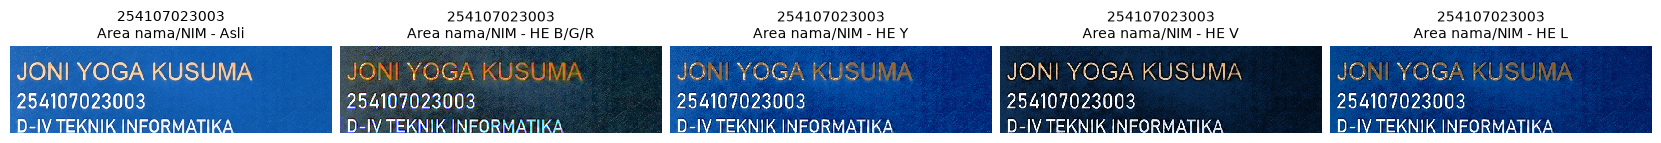

In [ ]:
def selisih_hue(asli,hasil):
    h1=cv.cvtColor(asli,cv.COLOR_BGR2HSV)[:,:,0].astype(np.int16)
    h2=cv.cvtColor(hasil,cv.COLOR_BGR2HSV)[:,:,0].astype(np.int16)
    d=np.abs(h1-h2)
    return float(2*np.minimum(d,180-d).mean())

print(f'{"Metode":<15}{"Hue (derajat)":>16}{"Rerata terang":>17}')
for nama,img in warna_ktm.items():
    print(f'{nama:<15}{selisih_hue(ktm["KTM1d.jpg"],img):>16.3f}{abu(img).mean():>17.2f}')

tampil([area(img,ROI_TEKS) for img in warna_ktm.values()],
       [f'Area nama/NIM - {nama}' for nama in warna_ktm],kolom=5,ukuran=3.3)

**Analisis:**
- HE B/G/R menggeser Hue paling besar, yaitu **59,56°**; latar dan warna pasfoto berubah jelas.
- Di antara Y/V/L, V dipilih karena rona pasfoto lebih mirip asli. Pergeseran Hue **1,22°**, tetapi rerata kecerahan turun menjadi **112,48**. Y sedikit lebih kecil (1,20°), tetapi pasfoto tampak lebih kelabu.
- Hue tidak selalu tetap karena pembulatan dan pembatasan nilai saat konversi warna.

### 5. HE Y dan CLAHE Y
Bandingkan kedua cara dengan parameter dari NIM.

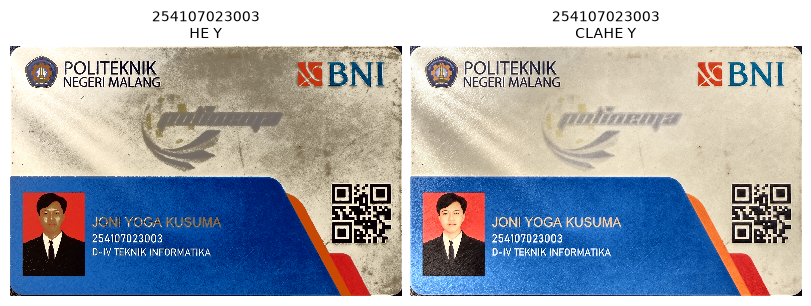

HE Y: Hue 1.197 derajat, rerata terang 131.08
CLAHE Y: Hue 0.136 derajat, rerata terang 159.11


In [ ]:
clahe_y=he_terang(ktm['KTM1d.jpg'],'Y',lokal=True)
perbandingan_y={'HE Y':warna_ktm['HE Y'],'CLAHE Y':clahe_y}
tampil(list(perbandingan_y.values()),list(perbandingan_y),kolom=2)
for nama,img in perbandingan_y.items():
    print(f'{nama}: Hue {selisih_hue(ktm["KTM1d.jpg"],img):.3f} derajat, '
          f'rerata terang {abu(img).mean():.2f}')

**Analisis:** CLAHE Y menggeser Hue **0,14°** dengan rerata kecerahan **159,11**. HE Y bergeser **1,20°** dengan rerata **131,08**. Pada foto ini, CLAHE Y lebih mendekati warna dan kecerahan asli.

## PERTANYAAN PRAKTIKUM E-2
### 1. Ekualisasi global KTM1a grayscale
Tampilkan gambar dan histogram sebelum/sesudah HE, lalu hitung PSNR.

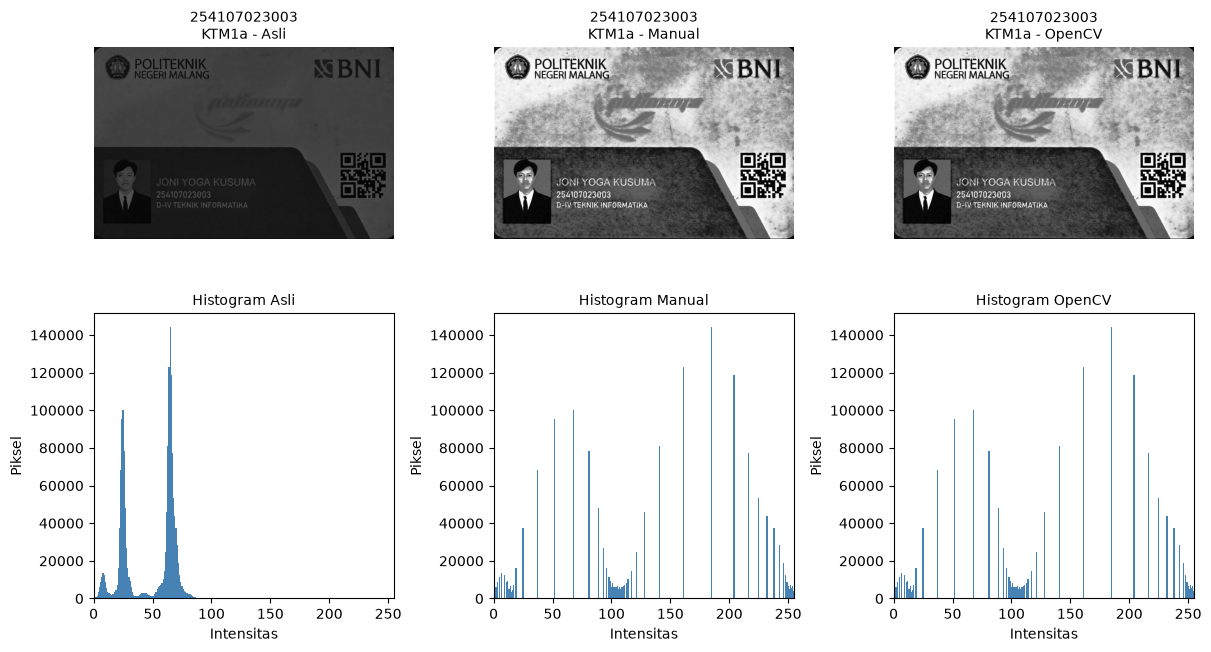

Selisih manual vs OpenCV: 0
PSNR asli vs manual: 8.06 dB
PSNR asli vs OpenCV: 8.06 dB


In [ ]:
gray_a=abu(ktm['KTM1a.jpg'])
manual_a=he_manual(gray_a)
global_a=cv.equalizeHist(gray_a)
fig,axes=plt.subplots(2,3,figsize=(12,6.5),layout='constrained')
for i,(nama,img) in enumerate([('Asli',gray_a),('Manual',manual_a),('OpenCV',global_a)]):
    axes[0,i].imshow(img,cmap='gray',vmin=0,vmax=255)
    axes[0,i].set_title(f'{NIM}\nKTM1a - {nama}');axes[0,i].axis('off')
    h=np.bincount(img.ravel(),minlength=256)
    axes[1,i].bar(np.arange(256),h,width=1,color='steelblue')
    axes[1,i].set(title=f'Histogram {nama}',xlabel='Intensitas',ylabel='Piksel',xlim=(0,255))
plt.show()

def psnr(a,b):
    mse=np.mean((a.astype(np.float64)-b.astype(np.float64))**2)
    return float('inf') if mse==0 else float(10*np.log10(255**2/mse))

print('Selisih manual vs OpenCV:',beda(manual_a,global_a))
print(f'PSNR asli vs manual: {psnr(gray_a,manual_a):.2f} dB')
print(f'PSNR asli vs OpenCV: {psnr(gray_a,global_a):.2f} dB')

**Analisis:** PSNR terhadap hasil HE adalah **8,06 dB**. Nilainya rendah karena intensitas berubah banyak, walaupun tulisan menjadi lebih tegas. PSNR tidak cukup untuk menilai keterbacaan teks.

### 2a. Global HE dan CLAHE
Gunakan clipLimit 2,5 dan grid 5 × 5 pada KTM1a.

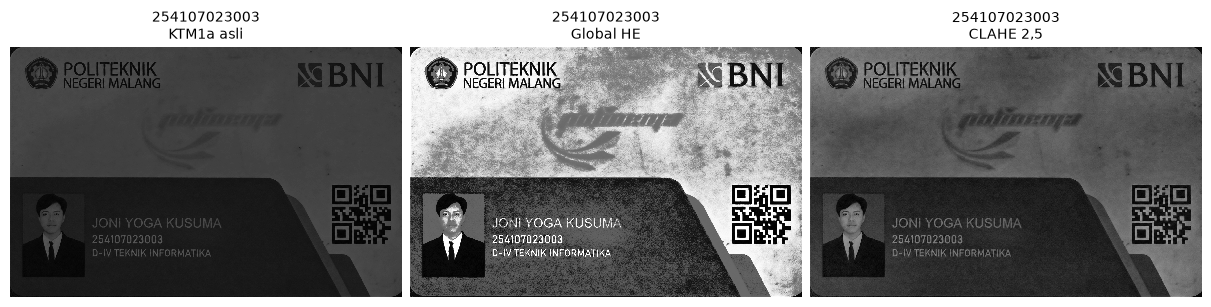

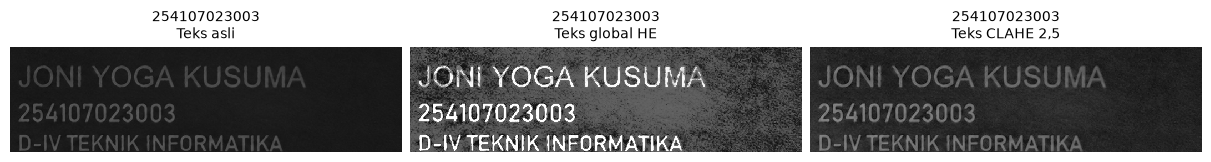

In [ ]:
def clahe(gray,clip):
    return cv.createCLAHE(clipLimit=float(clip),
                         tileGridSize=(PARAM['tile'],PARAM['tile'])).apply(gray)

clahe_a=clahe(gray_a,PARAM['clip'])
tampil([gray_a,global_a,clahe_a],['KTM1a asli','Global HE','CLAHE 2,5'])
tampil([area(img,ROI_TEKS) for img in [gray_a,global_a,clahe_a]],
       ['Teks asli','Teks global HE','Teks CLAHE 2,5'])

**Analisis:** Pada foto ini, nama dan NIM lebih tegas pada HE global, tetapi latarnya lebih berbintik. CLAHE 2,5 memberi hasil lebih halus, namun tulisan masih lebih gelap.

### 2b. Tiga clipLimit pembanding
Bandingkan 1,5; 2,0; dan 3,0 dengan nilai utama 2,5. Periksa area teks dan latar polos.

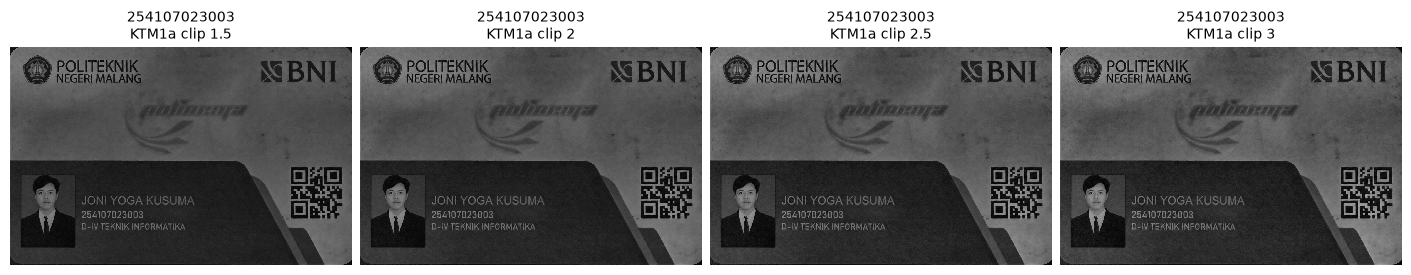

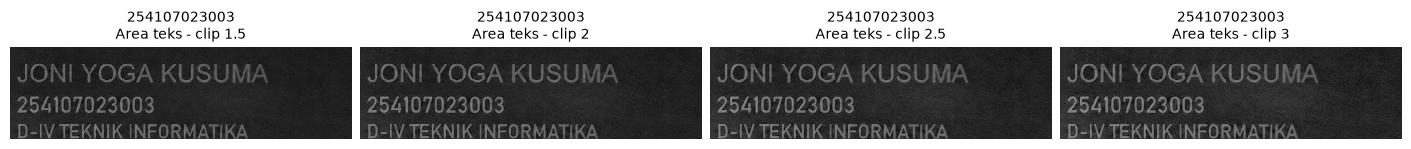

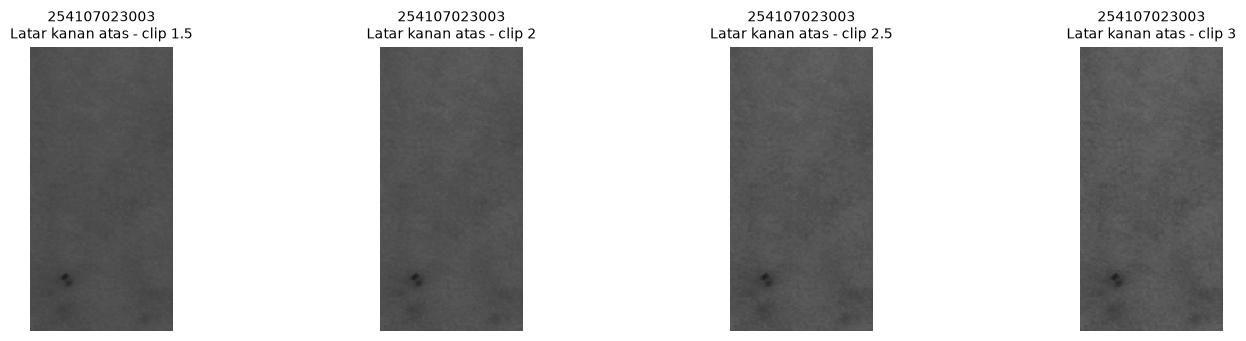

In [ ]:
nilai_clip=[PARAM['clip']-1,PARAM['clip']-0.5,PARAM['clip'],PARAM['clip']+0.5]
variasi=[clahe(gray_a,c) for c in nilai_clip]
tampil(variasi,[f'KTM1a clip {c:g}' for c in nilai_clip],kolom=4,ukuran=3.5)
tampil([area(img,ROI_TEKS) for img in variasi],
       [f'Area teks - clip {c:g}' for c in nilai_clip],kolom=4,ukuran=3.5)
tampil([area(img,ROI_NOISE) for img in variasi],
       [f'Latar kanan atas - clip {c:g}' for c in nilai_clip],kolom=4,ukuran=3.5)

**Analisis:** ClipLimit **2,5** dipilih sebagai kompromi: teks lebih jelas daripada 1,5, dengan bintik lebih ringan daripada 3,0. Saat naik ke 3,0, tekstur/bintik pada latar kanan atas sedikit lebih terlihat.

## E-3 TUGAS PRAKTIKUM DITHERING
### 1. Floyd-Steinberg
Sebarkan error ke kanan 7/16, bawah kiri 3/16, bawah 5/16, dan bawah kanan 1/16. Gunakan float dan batasi nilai 0–255 setiap pembaruan.

In [ ]:
def _langkah_fs(buffer, y, x, L, catat=False):
    H, W = buffer.shape
    step = 255.0 / (L - 1)
    lama = float(buffer[y, x])
    baru = float(np.rint(lama / step) * step)
    buffer[y, x] = baru
    error = lama - baru
    rincian = [] if catat else None

    for dy, dx, bobot, nama in (
        (0, 1, 7 / 16, 'Kanan'),
        (1, -1, 3 / 16, 'Bawah kiri'),
        (1, 0, 5 / 16, 'Bawah'),
        (1, 1, 1 / 16, 'Bawah kanan'),
    ):
        ny, nx = y + dy, x + dx
        if 0 <= ny < H and 0 <= nx < W:
            sebelum = float(buffer[ny, nx])
            tambahan = bobot * error
            # min/max adalah clipping skalar, ekuivalen np.clip(..., 0, 255).
            sesudah = min(255.0, max(0.0, sebelum + tambahan))
            buffer[ny, nx] = sesudah
            if catat:
                rincian.append((nama, sebelum, bobot, tambahan, sesudah))

    if catat:
        return {'lama': lama, 'baru': baru, 'error': error, 'tetangga': rincian}

def floyd_steinberg(gray, L=2):
    """FS grayscale: buffer float64, clipping setiap pembaruan tetangga."""
    if not isinstance(L, (int, np.integer)) or not 2 <= L <= 256:
        raise ValueError('L harus bilangan bulat antara 2 dan 256.')
    gray = np.asarray(gray)
    if gray.ndim != 2 or gray.size == 0:
        raise ValueError('Masukan harus citra grayscale 2D yang tidak kosong.')
    kerja = gray.astype(np.float64, copy=True)
    if not np.isfinite(kerja).all() or kerja.min() < 0 or kerja.max() > 255:
        raise ValueError('Intensitas masukan harus finite dan berada pada 0–255.')

    H, W = kerja.shape
    for y in range(H):
        for x in range(W):
            _langkah_fs(kerja, y, x, int(L))

    # Pembulatan ke uint8 hanya setelah difusi selesai. Untuk L=2 paletnya {0,255}.
    return np.rint(np.clip(kerja, 0, 255)).astype(np.uint8)

def floyd_steinberg_warna(bgr, L=2):
    """Difusi dilakukan terpisah, tanpa memindahkan galat antar kanal."""
    if bgr.ndim != 3 or bgr.shape[2] != 3:
        raise ValueError('Masukan warna harus memiliki tiga kanal BGR.')
    return cv.merge([floyd_steinberg(kanal, L) for kanal in cv.split(bgr)])

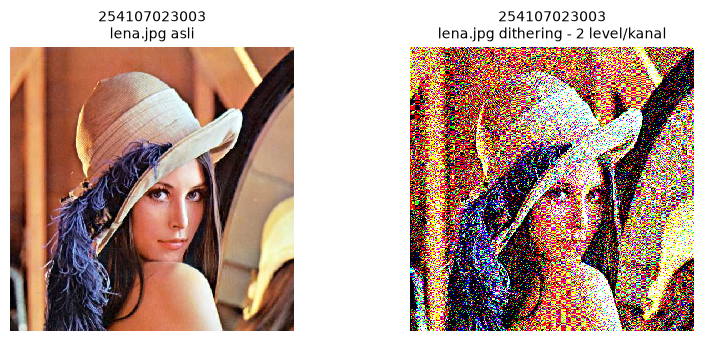

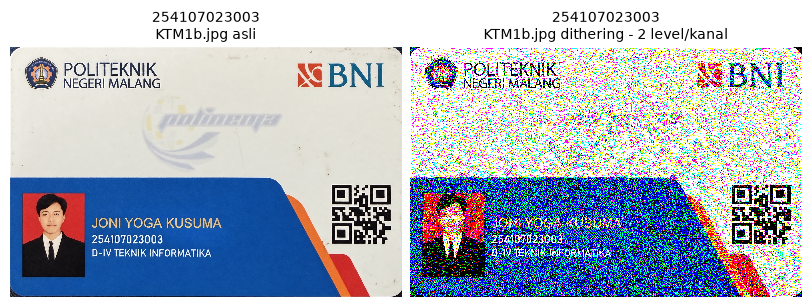

In [ ]:
for nama,img in [('lena.jpg',lena),('KTM1b.jpg',ktm['KTM1b.jpg'])]:
    hasil=floyd_steinberg_warna(img,L=PARAM['L'])
    assert np.isin(hasil,[0,255]).all()
    tampil([img,hasil],[f'{nama} asli',f'{nama} dithering - 2 level/kanal'],kolom=2)

**Analisis:** Dua level per kanal menghasilkan maksimal 8 warna. Pola titik membuat gradasi masih terlihat, tetapi tekstur menjadi lebih kasar.

### 2. Dithering langsung dan HE → dithering
Bandingkan kedua urutan pada Lena kontras rendah dan KTM1a.

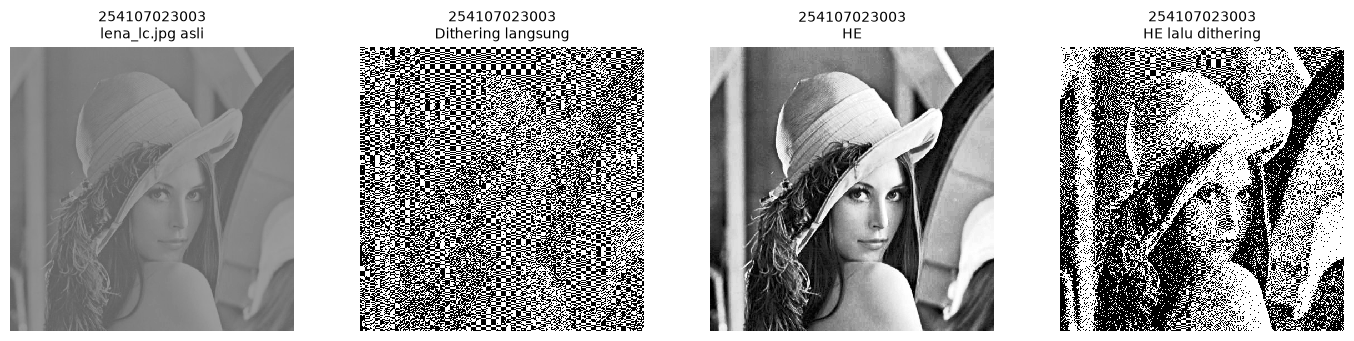

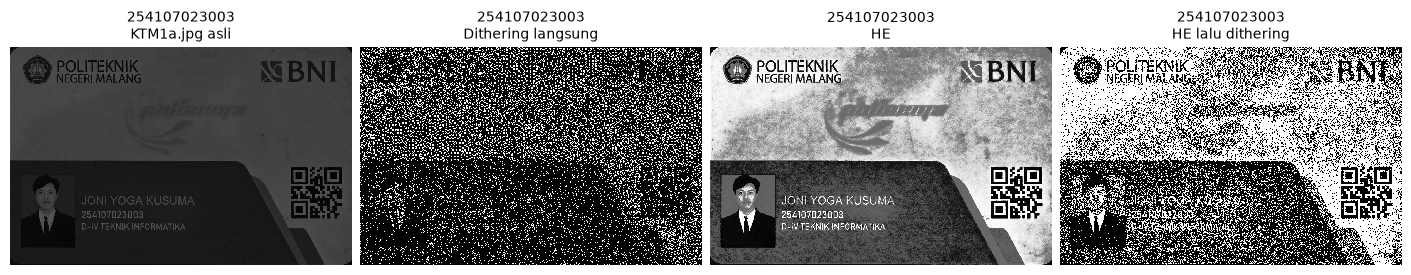

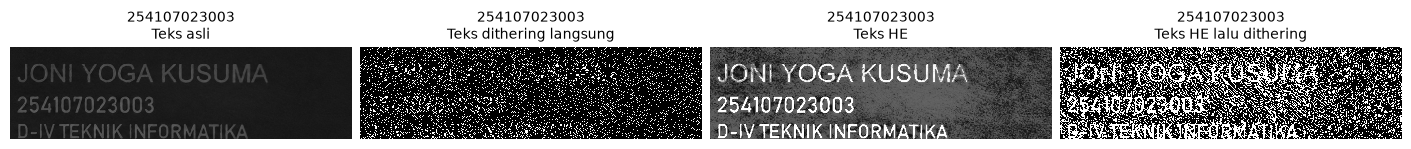

In [ ]:
hasil_dither={}
for nama,img in [('lena_lc.jpg',lena_lc),('KTM1a.jpg',ktm['KTM1a.jpg'])]:
    gray=abu(img)
    he=cv.equalizeHist(gray)
    langsung=floyd_steinberg(gray,PARAM['L'])
    setelah_he=floyd_steinberg(he,PARAM['L'])
    assert np.isin(langsung,[0,255]).all() and np.isin(setelah_he,[0,255]).all()
    tampil([gray,langsung,he,setelah_he],
           [f'{nama} asli','Dithering langsung','HE','HE lalu dithering'],
           kolom=4,ukuran=3.5)
    hasil_dither[nama]=[gray,langsung,he,setelah_he]

tampil([area(img,ROI_TEKS) for img in hasil_dither['KTM1a.jpg']],
       ['Teks asli','Teks dithering langsung','Teks HE','Teks HE lalu dithering'],
       kolom=4,ukuran=3.5)

**Analisis:** HE lalu dithering membuat nama dan NIM lebih mudah dikenali daripada dithering langsung. HE memperbesar kontras sebelum kuantisasi. Namun, pola titik juga membuat latar lebih kasar.